In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tempfile
import mlflow
import mlflow.sklearn
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report
)

# Load data
POLICY_PATH = "/Users/aleksandar.stojanovic/Downloads/ai_system/ml_scripts/data/processed/policy_model_data.parquet"
df = pd.read_parquet(POLICY_PATH)
X = np.vstack(df["features"].values)
y = df["target"].values
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Log confusion matrix
def log_confusion_matrix(cm, run_name):
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix - {run_name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as tmp:
        fig.savefig(tmp.name)
        mlflow.log_artifact(tmp.name, artifact_path="confusion_matrices")

# Log classification metrics
def log_classification_metrics(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    for label, metrics in report.items():
        if isinstance(metrics, dict):
            for metric_name, value in metrics.items():
                mlflow.log_metric(f"class_{label}_{metric_name}", value)
    return report


2025/12/08 00:53:48 INFO mlflow.tracking.fluent: Experiment with name 'policy_model_experiments' does not exist. Creating a new experiment.
2025/12/08 00:53:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


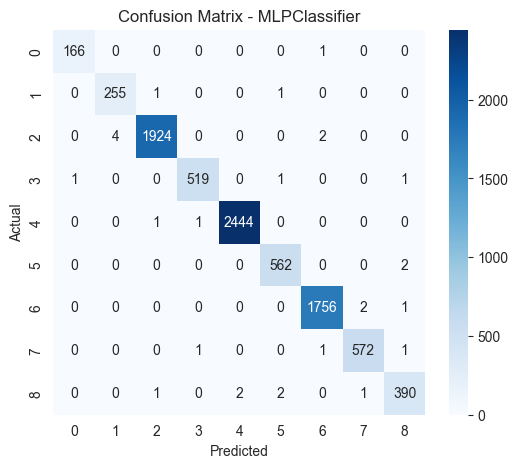

In [28]:
from sklearn.neural_network import MLPClassifier

mlflow.set_experiment("policy_model_experiments")

with mlflow.start_run(run_name="MLPClassifier_64x64"):
    start = time.time()

    model = MLPClassifier(hidden_layer_sizes=(64, 64), activation='relu', max_iter=300, random_state=42)
    model.fit(X_train, y_train)

    end = time.time()

    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    cm = confusion_matrix(y_val, y_pred)

    # === Log metrics and params ===
    mlflow.log_param("model_type", "MLPClassifier")
    mlflow.log_param("hidden_layers", "64x64")
    mlflow.log_param("activation", "relu")
    mlflow.log_param("max_iter", 300)
    mlflow.log_metric("val_accuracy", acc)
    mlflow.log_metric("training_time_sec", end - start)

    log_classification_metrics(y_val, y_pred)
    mlflow.sklearn.log_model(model, "policy_model")
    log_confusion_matrix(cm, "MLPClassifier")


2025/12/08 00:54:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


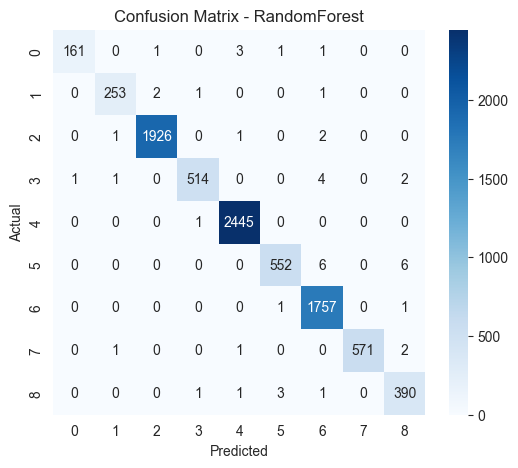

In [29]:
from sklearn.ensemble import RandomForestClassifier

with mlflow.start_run(run_name="RandomForest_100"):
    start = time.time()

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    end = time.time()

    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    cm = confusion_matrix(y_val, y_pred)

    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_metric("val_accuracy", acc)
    mlflow.log_metric("training_time_sec", end - start)

    log_classification_metrics(y_val, y_pred)
    mlflow.sklearn.log_model(model, "policy_model")
    log_confusion_matrix(cm, "RandomForest")


/Library/Frameworks/Python.framework/Versions/3.12/venv/ds2_dai3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
2025/12/08 00:54:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


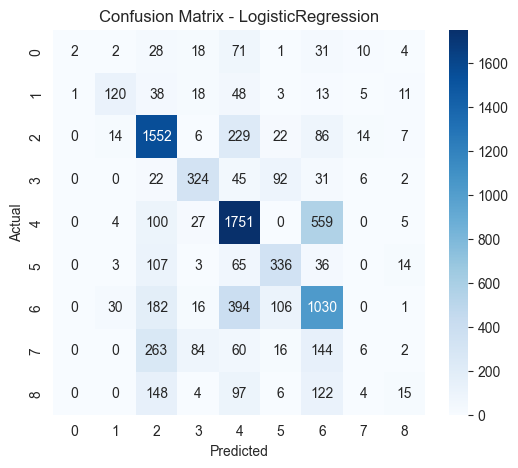

In [30]:
from sklearn.linear_model import LogisticRegression

with mlflow.start_run(run_name="LogisticRegression_L2"):
    start = time.time()

    model = LogisticRegression(max_iter=200, multi_class='multinomial', solver='lbfgs', random_state=42)
    model.fit(X_train, y_train)

    end = time.time()

    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    cm = confusion_matrix(y_val, y_pred)

    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("solver", "lbfgs")
    mlflow.log_param("max_iter", 200)
    mlflow.log_metric("val_accuracy", acc)
    mlflow.log_metric("training_time_sec", end - start)

    log_classification_metrics(y_val, y_pred)
    mlflow.sklearn.log_model(model, "policy_model")
    log_confusion_matrix(cm, "LogisticRegression")
